# Borrower Financial Stress & Loan Default Early Warning System

 **1.Data Loading and Understanding**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ucimlrepo -q

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

credit_data = fetch_ucirepo(id=350)

X = credit_data.data.features
y = credit_data.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30000, 24)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
import numpy as np

In [5]:
column_names = {
    "X1": "credit_limit",
    "X2": "sex",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",

    "X6": "payment_status_sep",
    "X7": "payment_status_aug",
    "X8": "payment_status_jul",
    "X9": "payment_status_jun",
    "X10": "payment_status_may",
    "X11": "payment_status_apr",

    "X12": "bill_amount_sep",
    "X13": "bill_amount_aug",
    "X14": "bill_amount_jul",
    "X15": "bill_amount_jun",
    "X16": "bill_amount_may",
    "X17": "bill_amount_apr",

    "X18": "payment_amount_sep",
    "X19": "payment_amount_aug",
    "X20": "payment_amount_jul",
    "X21": "payment_amount_jun",
    "X22": "payment_amount_may",
    "X23": "payment_amount_apr",

    "Y": "default_next_month"
}

df = df.rename(columns=column_names)

df.head()

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
df.tail()

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,50000,1,2,1,46,0,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [7]:
df.sample(5)

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
6103,60000,2,3,2,51,0,0,0,0,0,...,19212,19232,19218,2342,3057,700,700,682,700,0
12046,50000,1,2,2,25,0,0,0,0,0,...,28360,28831,29487,2141,1763,1161,1077,1167,1004,0
11799,280000,1,1,1,36,-2,-2,-2,-2,-2,...,17187,2848,5287,0,5240,17273,2861,5313,0,0
25548,30000,2,2,2,49,2,2,2,2,2,...,20182,19560,21241,1500,0,2500,0,2000,0,1
6391,330000,2,2,1,47,1,-2,-2,-1,-1,...,3155,4550,1264,0,0,3155,4550,1264,813,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   sex                 30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   payment_status_sep  30000 non-null  int64
 6   payment_status_aug  30000 non-null  int64
 7   payment_status_jul  30000 non-null  int64
 8   payment_status_jun  30000 non-null  int64
 9   payment_status_may  30000 non-null  int64
 10  payment_status_apr  30000 non-null  int64
 11  bill_amount_sep     30000 non-null  int64
 12  bill_amount_aug     30000 non-null  int64
 13  bill_amount_jul     30000 non-null  int64
 14  bill_amount_jun     30000 non-null  int64
 15  bill_amount_may     30000 non-null  int64
 16  bill_amount_apr     30000 non-null  int6

In [9]:
df.columns

Index(['credit_limit', 'sex', 'education', 'marital_status', 'age',
       'payment_status_sep', 'payment_status_aug', 'payment_status_jul',
       'payment_status_jun', 'payment_status_may', 'payment_status_apr',
       'bill_amount_sep', 'bill_amount_aug', 'bill_amount_jul',
       'bill_amount_jun', 'bill_amount_may', 'bill_amount_apr',
       'payment_amount_sep', 'payment_amount_aug', 'payment_amount_jul',
       'payment_amount_jun', 'payment_amount_may', 'payment_amount_apr',
       'default_next_month'],
      dtype='object')

In [10]:
df.describe()


,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [11]:
column_audit = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique()
})

column_audit

,data_type,missing_values,unique_values
credit_limit,int64,0,81
sex,int64,0,2
education,int64,0,7
marital_status,int64,0,4
age,int64,0,56
payment_status_sep,int64,0,11
payment_status_aug,int64,0,11
payment_status_jul,int64,0,11
payment_status_jun,int64,0,11
payment_status_may,int64,0,10


In [12]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 35


In [13]:
#DATA CLEANING
# - wrong DataType
# - Education column is in numerical order
# - change sex column from 1,2 numerical to string male and female
# - marital stauts column also contain 1,2, have to change that also
# - payyment status is also in numerical change to string ( from sept to etc)
# - default next month is in 1, 2 we can change if need.



**2. Data Cleaning**

In [14]:
category_columns = [
    "sex",
    "education",
    "marital_status",
    "default_next_month"
]

for column in category_columns:
    print(f"\n{column}:")
    print(df[column].value_counts().sort_index())


sex:
sex
1    11888
2    18112
Name: count, dtype: int64

education:
education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

marital_status:
marital_status
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

default_next_month:
default_next_month
0    23364
1     6636
Name: count, dtype: int64


In [15]:
# Create a copy of dataset
df_clean = df.copy()

In [16]:
df_clean.columns

Index(['credit_limit', 'sex', 'education', 'marital_status', 'age',
       'payment_status_sep', 'payment_status_aug', 'payment_status_jul',
       'payment_status_jun', 'payment_status_may', 'payment_status_apr',
       'bill_amount_sep', 'bill_amount_aug', 'bill_amount_jul',
       'bill_amount_jun', 'bill_amount_may', 'bill_amount_apr',
       'payment_amount_sep', 'payment_amount_aug', 'payment_amount_jul',
       'payment_amount_jun', 'payment_amount_may', 'payment_amount_apr',
       'default_next_month'],
      dtype='object')

In [17]:
# Add customer identifier basically 1,2,3 Id name.
df_clean.insert(0,"customer_id",range(1, len(df_clean)+1))

In [18]:
#Convert sex codes into labels
df_clean["sex"]= df_clean["sex"].map({
    1:"male",
    2:"female"
})

In [19]:
#Convert the unknown codes into known ( education column)

df_clean["education"] = df_clean["education"].replace({
    0:"unknown",
    3:"high_school",
    4:"others",
    2:"university",
    1:"graduate_school",
    5:"unknown",
    6:"unknown"
})

In [20]:
#Convert marital status into labels

df_clean["marital_status"] = df_clean["marital_status"].replace({
    0:"unknown",
    1:"married",
    2:"single",
    3:"others"
})

In [21]:
#Convert default status column into string from numerical for better readability
df_clean["default_next_month"] = df_clean["default_next_month"].map({
    0:"No default",
    1:"default"
})

In [22]:
# All above code run succesfully
df_clean.head()

,customer_id,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
0,1,20000,female,university,married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,default
1,2,120000,female,university,single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,default
2,3,90000,female,university,single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,No default
3,4,50000,female,university,married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,No default
4,5,50000,male,university,married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,No default


In [23]:
payment_status_columns = [
    "payment_status_apr",
    "payment_status_may",
    "payment_status_jun",
    "payment_status_jul",
    "payment_status_aug",
    "payment_status_sep"
]

for column in payment_status_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts().sort_index())


payment_status_apr
payment_status_apr
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

payment_status_may
payment_status_may
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

payment_status_jun
payment_status_jun
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

payment_status_jul
payment_status_jul
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

payment_status_aug
payment_status_aug
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

payment_status_sep
payment_status_sep


In [24]:
for column in payment_status_columns:
    new_column = column.replace("payment_status", "delay_months")

    df_clean[new_column] = df_clean[column].clip(lower=0)

df_clean[
    payment_status_columns +
    [column.replace("payment_status", "delay_months")
     for column in payment_status_columns]
].head()

,payment_status_apr,payment_status_may,payment_status_jun,payment_status_jul,payment_status_aug,payment_status_sep,delay_months_apr,delay_months_may,delay_months_jun,delay_months_jul,delay_months_aug,delay_months_sep
0,-2,-2,-1,-1,2,2,0,0,0,0,2,2
1,2,0,0,0,2,-1,2,0,0,0,2,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,-1,0,-1,0,0,0,0,0,0


In [25]:
#Check Numerical Columns for Impossible Values
important_numeric_columns = [
    "age",
    "credit_limit",
    "bill_amount_apr",
    "bill_amount_may",
    "bill_amount_jun",
    "bill_amount_jul",
    "bill_amount_aug",
    "bill_amount_sep",
    "payment_amount_apr",
    "payment_amount_may",
    "payment_amount_jun",
    "payment_amount_jul",
    "payment_amount_aug",
    "payment_amount_sep"
]

df_clean[important_numeric_columns].describe().T[
    ["min", "mean", "50%", "max"]
]

,min,mean,50%,max
age,21.0,35.485500,34.0,79.0
credit_limit,10000.0,167484.322667,140000.0,1000000.0
bill_amount_apr,-339603.0,38871.760400,17071.0,961664.0
bill_amount_may,-81334.0,40311.400967,18104.5,927171.0
bill_amount_jun,-170000.0,43262.948967,19052.0,891586.0
bill_amount_jul,-157264.0,47013.154800,20088.5,1664089.0
bill_amount_aug,-69777.0,49179.075167,21200.0,983931.0
bill_amount_sep,-165580.0,51223.330900,22381.5,964511.0
payment_amount_apr,0.0,5215.502567,1500.0,528666.0
payment_amount_may,0.0,4799.387633,1500.0,426529.0


In [26]:
#Count Unusual Financial Values
months = ["apr", "may", "jun", "jul", "aug", "sep"]

unusual_summary = []

for month in months:
    negative_bills = (df_clean[f"bill_amount_{month}"] < 0).sum()

    bills_over_limit = (
        df_clean[f"bill_amount_{month}"] > df_clean["credit_limit"]
    ).sum()

    zero_payments = (df_clean[f"payment_amount_{month}"] == 0).sum()

    unusual_summary.append({
        "month": month,
        "negative_bills": negative_bills,
        "bills_over_credit_limit": bills_over_limit,
        "zero_payments": zero_payments
    })

unusual_summary = pd.DataFrame(unusual_summary)

unusual_summary

,month,negative_bills,bills_over_credit_limit,zero_payments
0,apr,688,798,7173
1,may,655,820,6703
2,jun,675,1018,6408
3,jul,655,1583,5968
4,aug,669,1940,5396
5,sep,590,2115,5249


In [27]:
# Next Check: Risky Zero Payments
zero_payment_analysis = []

for month in months:
    no_payment_with_bill = (
        (df_clean[f"payment_amount_{month}"] == 0) &
        (df_clean[f"bill_amount_{month}"] > 0)
    ).sum()

    no_payment_no_bill = (
        (df_clean[f"payment_amount_{month}"] == 0) &
        (df_clean[f"bill_amount_{month}"] <= 0)
    ).sum()

    zero_payment_analysis.append({
        "month": month,
        "zero_payment_with_positive_bill": no_payment_with_bill,
        "zero_payment_with_no_bill": no_payment_no_bill
    })

zero_payment_analysis = pd.DataFrame(zero_payment_analysis)

zero_payment_analysis

,month,zero_payment_with_positive_bill,zero_payment_with_no_bill
0,apr,3469,3704
1,may,3546,3157
2,jun,3612,2796
3,jul,3396,2572
4,aug,3206,2190
5,sep,3495,1754


In [28]:
print("Final rows:", df_clean.shape[0])
print("Final columns:", df_clean.shape[1])
print("Missing values:", df_clean.isnull().sum().sum())
print("Target values:", df_clean["default_next_month"].unique())

Final rows: 30000
Final columns: 31
Missing values: 0
Target values: ['default' 'No default']


In [29]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
#Save the Cleaned Dataset
df_clean.to_csv(
    "/content/drive/MyDrive/slice-credit-risk-analysis/Data/credit_data_cleaned.csv",
    index=False
)

In [31]:
df_clean.head()

,customer_id,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month,delay_months_apr,delay_months_may,delay_months_jun,delay_months_jul,delay_months_aug,delay_months_sep
0,1,20000,female,university,married,24,2,2,-1,-1,...,0,0,0,default,0,0,0,0,2,2
1,2,120000,female,university,single,26,-1,2,0,0,...,1000,0,2000,default,2,0,0,0,2,0
2,3,90000,female,university,single,34,0,0,0,0,...,1000,1000,5000,No default,0,0,0,0,0,0
3,4,50000,female,university,married,37,0,0,0,0,...,1100,1069,1000,No default,0,0,0,0,0,0
4,5,50000,male,university,married,57,-1,0,-1,0,...,9000,689,679,No default,0,0,0,0,0,0


In [32]:
# Stage 4.1: Create Credit Utilization
for month in months:  # month is a loop variable

    # bill_for_calculation is a temporary variable/Series
    bill_for_calculation = df_clean[
        f"bill_amount_{month}"
    ].clip(lower=0)

    # This creates a new column for each month
    df_clean[f"credit_utilization_{month}"] = (
        bill_for_calculation / df_clean["credit_limit"]*100
    ).round(2)


In [33]:
# Display selected existing and newly created columns
df_clean[[
    "credit_limit",
    "bill_amount_sep",
    "credit_utilization_sep"
]].head(10)

,credit_limit,bill_amount_sep,credit_utilization_sep
0,20000,3913,19.56
1,120000,2682,2.24
2,90000,29239,32.49
3,50000,46990,93.98
4,50000,8617,17.23
5,50000,64400,128.80
6,500000,367965,73.59
7,100000,11876,11.88
8,140000,11285,8.06
9,20000,0,0.00


Calculate 6-Month Average Utilization

In [34]:
# utilization_columns is a variable containing six column names
utilization_columns = [
    f"credit_utilization_{month}" for month in months
]

# This creates a new column
df_clean["avg_credit_utilization_6m"] = (
    df_clean[utilization_columns]
    .mean(axis=1)
    .round(2)
)

In [35]:
df_clean[[
    "customer_id",
    "credit_utilization_apr",
    "credit_utilization_sep",
    "avg_credit_utilization_6m"
]].head(10)

,customer_id,credit_utilization_apr,credit_utilization_sep,avg_credit_utilization_6m
0,1,0.00,19.56,6.42
1,2,2.72,2.24,2.38
2,3,17.28,32.49,18.83
3,4,59.09,93.98,77.11
4,5,38.26,17.23,36.44
5,6,40.05,128.80,79.37
6,7,94.79,73.59,90.82
7,8,0.57,11.88,2.28
8,9,2.66,8.06,7.76
9,10,69.56,0.00,22.43


In [36]:
# early_months is a variable containing early-period column names
early_months = [
    "credit_utilization_apr",
    "credit_utilization_may",
    "credit_utilization_jun"
]

# recent_months is a variable containing recent-period column names
recent_months = [
    "credit_utilization_jul",
    "credit_utilization_aug",
    "credit_utilization_sep"
]

# This creates the early three-month average column
df_clean["early_utilization_avg"] = (
    df_clean[early_months].mean(axis=1).round(2)
)

# This creates the recent three-month average column
df_clean["recent_utilization_avg"] = (
    df_clean[recent_months].mean(axis=1).round(2)
)

# This creates the utilization-change column
df_clean["utilization_change"] = (
    df_clean["recent_utilization_avg"]
    - df_clean["early_utilization_avg"]
).round(2)

In [37]:
df_clean[[
    "customer_id",
    "credit_utilization_apr",
    "credit_utilization_sep",
    "avg_credit_utilization_6m",
    "early_utilization_avg",
    "recent_utilization_avg",
    "utilization_change"
]].head(5)

,customer_id,credit_utilization_apr,credit_utilization_sep,avg_credit_utilization_6m,early_utilization_avg,recent_utilization_avg,utilization_change
0,1,0.00,19.56,6.42,0.00,12.84,12.84
1,2,2.72,2.24,2.38,2.78,1.97,-0.81
2,3,17.28,32.49,18.83,16.60,21.05,4.45
3,4,59.09,93.98,77.11,57.88,96.34,38.46
4,5,38.26,17.23,36.44,39.48,33.41,-6.07


Measure Repeated Payment Delays

In [38]:
# delay_columns is a variable containing six delay column names
delay_columns = [
    f"delay_months_{month}" for month in months
]

# This creates a column counting months with a payment delay
df_clean["months_with_delay"] = (
    df_clean[delay_columns]
    .gt(0)
    .sum(axis=1)
)

# This creates a column showing the customer's maximum delay
df_clean["maximum_delay_months"] = (
    df_clean[delay_columns]
    .max(axis=1)
)

In [39]:
df_clean[[
    "customer_id",
    "months_with_delay",
    "maximum_delay_months"
]].head(5)

,customer_id,months_with_delay,maximum_delay_months
0,1,2,2
1,2,2,2
2,3,0,0
3,4,0,0
4,5,0,0


**Check Whether Payment Delay Is Worsening**

In [40]:
# early_delay_columns is a variable containing early-period column names
early_delay_columns = [
    "delay_months_apr",
    "delay_months_may",
    "delay_months_jun"
]

# recent_delay_columns is a variable containing recent-period column names
recent_delay_columns = [
    "delay_months_jul",
    "delay_months_aug",
    "delay_months_sep"
]

# This creates the early-period average-delay column
df_clean["early_delay_avg"] = (
    df_clean[early_delay_columns]
    .mean(axis=1)
    .round(2)
)

# This creates the recent-period average-delay column
df_clean["recent_delay_avg"] = (
    df_clean[recent_delay_columns]
    .mean(axis=1)
    .round(2)
)

# This creates the change-in-delay column
df_clean["delay_change"] = (
    df_clean["recent_delay_avg"]
    - df_clean["early_delay_avg"]
).round(2)

In [41]:
# Checking the columns
df_clean[[
    "customer_id",
    "early_delay_avg",
    "recent_delay_avg",
    "delay_change",
    "maximum_delay_months"
]].head(20)

,customer_id,early_delay_avg,recent_delay_avg,delay_change,maximum_delay_months
0,1,0.00,1.33,1.33,2
1,2,0.67,0.67,0.00,2
2,3,0.00,0.00,0.00,0
3,4,0.00,0.00,0.00,0
4,5,0.00,0.00,0.00,0
5,6,0.00,0.00,0.00,0
6,7,0.00,0.00,0.00,0
7,8,0.00,0.00,0.00,0
8,9,0.00,0.67,0.67,2
9,10,0.00,0.00,0.00,0


 **Count Zero Payments Despite Having a Bill**

In [42]:
# no_payment_flag_columns is a variable for storing new flag column names
no_payment_flag_columns = []

for month in months:  # month is a loop variable

    # flag_column is a variable containing the new column name
    flag_column = f"no_payment_with_bill_{month}"

    # This creates a monthly flag column: 1 = warning, 0 = no warning
    df_clean[flag_column] = (
        (df_clean[f"payment_amount_{month}"] == 0) &
        (df_clean[f"bill_amount_{month}"] > 0)
    ).astype(int)

    no_payment_flag_columns.append(flag_column)

# This creates a column counting total warning months
df_clean["months_no_payment_with_bill"] = (
    df_clean[no_payment_flag_columns].sum(axis=1)
)

In [43]:
df_clean[[
    "customer_id",
    "months_no_payment_with_bill",
    "default_next_month"
]].head(20)

,customer_id,months_no_payment_with_bill,default_next_month
0,1,2,default
1,2,2,default
2,3,0,No default
3,4,0,No default
4,5,0,No default
5,6,0,No default
6,7,0,No default
7,8,1,No default
8,9,1,No default
9,10,1,No default


### **Saved feature engineered dataset**

In [44]:
df_clean.to_csv(
    "/content/drive/MyDrive/slice-credit-risk-analysis/Data/credit_data_features.csv",
    index=False
)

***STAGE 4 :- EDA ka first question:***
Total customers mein kitne default hue aur kitne nahi?

## Exploratory Data Analysis — Questions

The purpose of this EDA is to understand borrower behaviour and identify possible early-warning signs of default.

We will answer the following questions:

1. What is the overall default rate?
2. Do customers with high credit utilization have a higher default rate?
3. Does increasing credit utilization indicate higher default risk?
4. Do customers with previous payment delays default more often?
5. Does a longer maximum payment delay increase default risk?

In [45]:
# This creates a new numeric target column - beacuse our default next month column have string value which we cant able to sum so we converted it into 0,1
df_clean["default_flag"] = df_clean["default_next_month"].map({
    "No default": 0,
    "default": 1
})

What is the overall default rate?

In [46]:
# Total unique customers
total_customers = df_clean["customer_id"].nunique()

# Since default_flag contains 0 and 1, sum gives total defaults
default_customers = df_clean["default_flag"].sum()

# Calculate customers who did not default
no_default_customers = total_customers - default_customers

# Calculate default percentage
default_rate = (default_customers / total_customers) * 100

print("Total customers:", total_customers)
print("Default customers:", default_customers)
print("No-default customers:", no_default_customers)
print("Default rate:", round(default_rate, 2), "%")

Total customers: 30000
Default customers: 6636
No-default customers: 23364
Default rate: 22.12 %


Do customers with high credit utilization have a higher default rate?

In [47]:
# utilization_bins is a variable storing range boundaries
utilization_bins = [-0.01, 30, 60, 100, float("inf")]

# utilization_labels is a variable storing group names
utilization_labels = [
    "Low (0-30%)",
    "Moderate (30-60%)",
    "High (60-100%)",
    "Over Limit (>100%)"
]

# This creates a new utilization-group column
df_clean["utilization_band"] = pd.cut(
    df_clean["avg_credit_utilization_6m"],
    bins=utilization_bins,
    labels=utilization_labels
)

In [48]:
# utilization_analysis is a variable storing grouped results
utilization_analysis = (
    df_clean.groupby("utilization_band", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# This creates default-rate percentage
utilization_analysis["default_rate_pct"] = (
    utilization_analysis["default_customers"]
    / utilization_analysis["total_customers"]
    * 100
).round(2)

utilization_analysis

,utilization_band,total_customers,default_customers,default_rate_pct
0,Low (0-30%),15259,2730,17.89
1,Moderate (30-60%),5474,1201,21.94
2,High (60-100%),8631,2488,28.83
3,Over Limit (>100%),636,217,34.12


### Finding: Credit Utilization and Default

Default rate increased steadily with average credit utilization. Low-utilization customers had a 17.89% default rate, while customers exceeding their credit limit had a 34.12% default rate. The over-limit group showed nearly 1.9 times the default risk of the low-utilization group. This suggests that high credit utilization is an important early-warning signal, although statistical testing is required before confirming the relationship.

# EDA Question 3: Does Increasing Utilization Raise Default Risk?italicized text

In [49]:
# trend_bins is a variable storing range boundaries
trend_bins = [
    float("-inf"),
    -10,
    10,
    float("inf")
]

# trend_labels is a variable storing group names
trend_labels = [
    "Improving",
    "Stable",
    "Worsening"
]

# This creates a new utilization-trend column
df_clean["utilization_trend"] = pd.cut(
    df_clean["utilization_change"],
    bins=trend_bins,
    labels=trend_labels
)

In [50]:
# utilization_trend_analysis is a variable storing grouped results
utilization_trend_analysis = (
    df_clean.groupby("utilization_trend", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# This creates the default-rate percentage column
utilization_trend_analysis["default_rate_pct"] = (
    utilization_trend_analysis["default_customers"]
    / utilization_trend_analysis["total_customers"]
    * 100
).round(2)

utilization_trend_analysis

,utilization_trend,total_customers,default_customers,default_rate_pct
0,Improving,1989,478,24.03
1,Stable,20087,4570,22.75
2,Worsening,7924,1588,20.04


In [51]:
# trend_labels is a variable storing neutral group names
trend_labels = [
    "Decreasing",
    "Stable",
    "Increasing"
]

# Update the existing utilization-trend column
df_clean["utilization_trend"] = pd.cut(
    df_clean["utilization_change"],
    bins=trend_bins,
    labels=trend_labels
)

In [52]:
# trend_profile is a variable storing each group's behaviour
trend_profile = (
    df_clean.groupby("utilization_trend", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        early_utilization=("early_utilization_avg", "mean"),
        recent_utilization=("recent_utilization_avg", "mean"),
        average_delay=("maximum_delay_months", "mean"),
        default_rate=("default_flag", "mean")
    )
    .round(2)
    .reset_index()
)

# Convert default rate into percentage
trend_profile["default_rate"] = (
    trend_profile["default_rate"] * 100
).round(2)

trend_profile

,utilization_trend,total_customers,early_utilization,recent_utilization,average_delay,default_rate
0,Decreasing,1989,61.73,38.68,0.93,24.0
1,Stable,20087,28.03,27.89,0.73,23.0
2,Increasing,7924,41.22,74.55,0.51,20.0


Actual finding:

### Sirf utilization ka badhna ya ghatna customer ka risk decide nahi karta. Payment-delay history ko saath dekhna zaroori hai.

# EDA Question 4: Does Longer Payment Delay Increase Default Risk?

In [53]:
# This creates a new maximum-delay group column
df_clean["delay_group"] = pd.cut(
    df_clean["maximum_delay_months"],
    bins=[-0.01, 0, 1, 2, float("inf")],
    labels=[
        "No Delay",
        "1 Month",
        "2 Months",
        "3+ Months"
    ]
)

# delay_analysis is a variable storing grouped results
delay_analysis = (
    df_clean.groupby("delay_group", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# This calculates each group's default percentage
delay_analysis["default_rate_pct"] = (
    delay_analysis["default_customers"]
    / delay_analysis["total_customers"]
    * 100
).round(2)

delay_analysis

,delay_group,total_customers,default_customers,default_rate_pct
0,No Delay,19931,2334,11.71
1,1 Month,1689,422,24.99
2,2 Months,7187,3130,43.55
3,3+ Months,1193,750,62.87


### Finding: Maximum Payment Delay and Default

Default risk increased strongly with the length of previous payment delay. Customers with no recorded delay had an 11.71% default rate, while customers with delays of three months or more had a 62.87% default rate.

The serious-delay group showed approximately 5.4 times the default risk of customers with no delay. Maximum previous payment delay is therefore one of the strongest early-warning signals identified in this analysis.

# EDA Question 5: Does the number of months showing payment delay increase the default risk?

In [54]:
# repeated_delay_analysis stores grouped results
repeated_delay_analysis = (
    df_clean.groupby("months_with_delay")
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# This creates the default-rate percentage column
repeated_delay_analysis["default_rate_pct"] = (
    repeated_delay_analysis["default_customers"]
    / repeated_delay_analysis["total_customers"]
    * 100
).round(2)

repeated_delay_analysis

,months_with_delay,total_customers,default_customers,default_rate_pct
0,0,19931,2334,11.71
1,1,4426,1320,29.82
2,2,1899,736,38.76
3,3,1154,587,50.87
4,4,951,545,57.31
5,5,298,171,57.38
6,6,1341,943,70.32


### Finding: Repeated Payment Delays and Default

Default risk generally increased with the number of monthly records showing payment delay. Customers with no recorded delay had an 11.71% default rate, while customers showing delay in all six monthly records had a 70.32% default rate.

The six-month delay-history group showed approximately six times the default risk of customers with no delay. This suggests that repeated signs of delinquency are a powerful early-warning indicator.

## Stage 5: Statistical Analysis

**Test 1: Chi-Square Test**

## Statistical Test 1: Chi-Square Test

**Question:** Is payment-delay severity connected with next-month default?

- **H₀:** Payment delay and default are not connected.
- **H₁:** Payment delay and default are connected.

**Decision:** If the p-value is below 0.05, we will reject H₀.

In [55]:
# contingency_table is a variable storing customer counts
contingency_table = pd.crosstab(
    df_clean["delay_group"],
    df_clean["default_flag"]
)

contingency_table

default_flag,0,1
delay_group,,
No Delay,17597,2334
1 Month,1267,422
2 Months,4057,3130
3+ Months,443,750


In [56]:
from scipy.stats import chi2_contingency

# Run the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square value:", round(chi2, 2))
print("P-value:", p_value)

Chi-square value: 4327.6
P-value: 0.0


### Chi-Square Test Result

The Chi-square test produced a statistic of 4327.60 with a p-value below 0.05. Therefore, the null hypothesis was rejected.

There is statistically significant evidence that previous payment-delay severity is associated with next-month default. The differences observed between the delay groups are highly unlikely to be explained by random chance alone.

This test shows association, not direct causation.

In [57]:
#--------------------------------------------------------------------------------------------------------------------------------------------

## Relationship Strength: Cramér's V

The Chi-square test confirmed that payment delay and default are associated. Cramér's V is now used to measure the strength of this relationship.

In [58]:
from scipy.stats.contingency import association

# cramers_v stores the relationship-strength result
cramers_v = association(
    contingency_table,
    method="cramer"
)

print("Cramér's V:", round(cramers_v, 3))

Cramér's V: 0.38


Final conclusion:

Previous payment-delay severity and next-month default have a statistically significant and strong relationship.

## Statistical Analysis 2:  95% Confidence Intervals

## Statistical Analysis 2: 95% Confidence Intervals

**Question:** What is the likely range of the true default rate for each payment-delay group?

A 95% confidence interval will be calculated for every delay group. A narrow interval indicates a more precise estimate, while a wide interval indicates greater uncertainty.

In [59]:
from statsmodels.stats.proportion import proportion_confint

# delay_confidence_intervals stores a copy of delay results
delay_confidence_intervals = delay_analysis.copy()

# Calculate lower and upper confidence limits
lower_limit, upper_limit = proportion_confint(
    count=delay_confidence_intervals["default_customers"],
    nobs=delay_confidence_intervals["total_customers"],
    alpha=0.05,
    method="wilson"
)

# Create lower-limit percentage column
delay_confidence_intervals["ci_lower_pct"] = (
    lower_limit * 100
).round(2)

# Create upper-limit percentage column
delay_confidence_intervals["ci_upper_pct"] = (
    upper_limit * 100
).round(2)

delay_confidence_intervals[[
    "delay_group",
    "total_customers",
    "default_rate_pct",
    "ci_lower_pct",
    "ci_upper_pct"
]]

,delay_group,total_customers,default_rate_pct,ci_lower_pct,ci_upper_pct
0,No Delay,19931,11.71,11.27,12.16
1,1 Month,1689,24.99,22.98,27.11
2,2 Months,7187,43.55,42.41,44.70
3,3+ Months,1193,62.87,60.09,65.56


### Analysis 2 Finding: Confidence Intervals

The estimated default rate increased from 11.71% among customers with no previous delay to 62.87% among customers with delays of three months or more.

The 95% confidence interval for the no-delay group was 11.27% to 12.16%, while the interval for the serious delay group was 60.09% to 65.56%. These ranges do not overlap, showing a clear and practically meaningful separation between the groups.

The serious delay group had a wider interval because it contained fewer customers, resulting in slightly greater uncertainty.

# Statistical Analysis 3: Logistic Regression

**Question:** When important warning signals are considered **together** , which factors remain significantly associated with next month default?

**The analysis includes:**

- Six-month average credit utilization
- Number of monthly records showing payment delay
- Maximum payment delay
- Number of months with a positive bill but zero payment

**The target variable is next-month default:**

- 0 = No Default
- 1 = Default

In [60]:
import statsmodels.api as sm

# Create utilization in units of 10 percentage points
df_clean["utilization_per_10pct"] = (
    df_clean["avg_credit_utilization_6m"] / 10
)

# predictor_columns stores the warning-signal column names
predictor_columns = [
    "utilization_per_10pct",
    "months_with_delay",
    "maximum_delay_months",
    "months_no_payment_with_bill"
]

# X stores the warning signals
X = df_clean[predictor_columns]

# Add the model's constant/intercept
X = sm.add_constant(X)

# y stores the default result
y = df_clean["default_flag"]

In [61]:
# logistic_model stores the fitted regression model
logistic_model = sm.Logit(y, X).fit(disp=False)

# Create a simple result table
logistic_results = pd.DataFrame({
    "odds_ratio": np.exp(logistic_model.params),
    "p_value": logistic_model.pvalues
}).round(4)

logistic_results

,odds_ratio,p_value
const,0.1366,0.0000
utilization_per_10pct,1.0135,0.0034
months_with_delay,1.3799,0.0000
maximum_delay_months,1.4659,0.0000
months_no_payment_with_bill,0.9876,0.5124


## Analysis 3 Finding: Which Warning Signs Matter Most?

Logistic regression was used to study all warning signals together.

- **Maximum payment delay was the strongest signal.** Each additional month in the worst recorded delay was linked with approximately **46.6% higher default odds**.
- **Repeated delay was also important.** Each additional monthly record showing delay was linked with approximately **38% higher default odds**.
- **Credit utilization had a small effect.** A 10-percentage-point increase in utilization was linked with only **1.35% higher default odds**.
- **Zero payment despite having a bill was not statistically significant** after payment-delay history and utilization were considered.

### Business Meaning

Previous payment delay is more useful for identifying risky customers than credit utilization alone. The early-warning system should therefore give the highest importance to:

1. How long the customer’s worst delay lasted
2. How many monthly records showed a delay
3. The customer’s average credit utilization

Zero-payment count should not receive major weight because it did not provide useful additional evidence after the other factors were considered.

> These results show statistical relationships, not direct cause and effect.

## Statistical Analysis 4: Odds-Ratio Confidence Intervals

A 95% confidence interval is calculated for every logistic-regression odds ratio to check the precision of each estimated effect.

If the interval includes 1, the factor may not have a statistically meaningful effect.

In [62]:
# regression_confidence stores the model's confidence limits
regression_confidence = logistic_model.conf_int()

# odds_ratio_results stores odds ratios and their confidence intervals
odds_ratio_results = pd.DataFrame({
    "odds_ratio": np.exp(logistic_model.params),
    "ci_lower": np.exp(regression_confidence[0]),
    "ci_upper": np.exp(regression_confidence[1]),
    "p_value": logistic_model.pvalues
}).round(4)

odds_ratio_results

,odds_ratio,ci_lower,ci_upper,p_value
const,0.1366,0.1296,0.1441,0.0000
utilization_per_10pct,1.0135,1.0045,1.0227,0.0034
months_with_delay,1.3799,1.3402,1.4207,0.0000
maximum_delay_months,1.4659,1.4003,1.5347,0.0000
months_no_payment_with_bill,0.9876,0.9514,1.0252,0.5124


### Analysis 4 Finding: Odds-Ratio Confidence Intervals

The confidence intervals confirmed that payment-delay behaviour was the most reliable default warning signal.

- Each additional monthly record showing delay was associated with approximately 34%–42% higher default odds.
- Each additional month in the maximum recorded delay was associated with approximately 40%–53% higher default odds.
- Credit utilization had a statistically significant but small effect.
- The confidence interval for zero payment with a positive bill included 1, meaning its independent effect was uncertain.

These results support giving the greatest importance to the frequency and severity of previous payment delays.

## Final Model Check: Multicollinearity

Variance Inflation Factor (VIF) is used to check whether the logistic-regression **predictors** repeat too much of the same information.

A VIF below 5 is treated as acceptable for this analysis.

In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# vif_values is a variable storing calculated VIF scores
vif_values = []

# Calculate VIF for every column in X
for column_number in range(X.shape[1]):
    vif_score = variance_inflation_factor(
        X.values,
        column_number
    )

    vif_values.append(vif_score)

# Create a readable VIF result table
vif_results = pd.DataFrame({
    "feature": X.columns,
    "vif": vif_values
})

# Remove const because it is not a business predictor
vif_results = vif_results[
    vif_results["feature"] != "const"
].round(2)

vif_results

,feature,vif
1,utilization_per_10pct,1.15
2,months_with_delay,3.30
3,maximum_delay_months,3.39
4,months_no_payment_with_bill,1.70


### Final Model Check: Multicollinearity

All predictor VIF values were below 5, indicating that the model did not have a serious multicollinearity problem.

The two payment-delay features had moderate overlap because both describe repayment behaviour, but their VIF values of 3.30 and 3.39 remained acceptable.

Therefore, the predictors were not repeating enough information to make the logistic-regression results unstable.

# Stage 6: Risk Segmentation
  Rule-Based Risk Segmentation

In [64]:
# risk_conditions is a variable storing business rules
risk_conditions = [
    (
        (df_clean["maximum_delay_months"] >= 3) |
        (df_clean["months_with_delay"] >= 5)
    ),
    (
        (df_clean["maximum_delay_months"] == 2) |
        (df_clean["avg_credit_utilization_6m"] > 100)
    ),
    (
        (df_clean["maximum_delay_months"] == 1) |
        (df_clean["avg_credit_utilization_6m"] >= 60)
    )
]

# risk_labels is a variable storing segment names
risk_labels = [
    "Critical Risk",
    "High Risk",
    "Watchlist"
]

# This creates the final customer-risk segment column
df_clean["risk_segment"] = np.select(
    risk_conditions,
    risk_labels,
    default="Low Risk"
)

In [78]:
# risk_segment_analysis stores segment results
risk_segment_analysis = (
    df_clean.groupby("risk_segment")
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# Calculate each segment's default rate
risk_segment_analysis["default_rate_pct"] = (
    risk_segment_analysis["default_customers"]
    / risk_segment_analysis["total_customers"]
    * 100
).round(2)

risk_segment_analysis.sort_values(
    "default_rate_pct"
)

,risk_segment,total_customers,default_customers,default_rate_pct
2,Low Risk,14610,1590,10.88
3,Watchlist,6700,1114,16.63
1,High Risk,6494,2509,38.64
0,Critical Risk,2196,1423,64.80


## Risk-Segment Validation

The rule based segmentation produced a clear increase in default risk:

- Low Risk: 10.88%
- Watchlist: 16.63%
- High Risk: 38.64%
- Critical Risk: 64.80%

Critical risk customers had approximately six times the default rate of low risk customers.

The High and Critical segments contained around 29% of all customers but captured approximately 59% of all defaults. This allows the lender to focus monitoring and support efforts on a smaller, higher-risk group instead of treating every customer equally.

The segmentation rules are an educational prototype and would require further validation before real-world lending use.

In [66]:
# action_map is a variable connecting segments with business actions
action_map = {
    "Low Risk": (
        "Continue normal service and routine monitoring"
    ),
    "Watchlist": (
        "Monitor closely and send early payment reminders"
    ),
    "High Risk": (
        "Contact customer and review before increasing credit"
    ),
    "Critical Risk": (
        "Urgent human review and offer repayment support"
    )
}

# This creates a new recommended-action column
df_clean["recommended_action"] = (
    df_clean["risk_segment"].map(action_map)
)

In [67]:
df_clean[[
    "customer_id",
    "risk_segment",
    "recommended_action"
]].head(20)

,customer_id,risk_segment,recommended_action
0,1,High Risk,Contact customer and review before increasing ...
1,2,High Risk,Contact customer and review before increasing ...
2,3,Low Risk,Continue normal service and routine monitoring
3,4,Watchlist,Monitor closely and send early payment reminders
4,5,Low Risk,Continue normal service and routine monitoring
5,6,Watchlist,Monitor closely and send early payment reminders
6,7,Watchlist,Monitor closely and send early payment reminders
7,8,Low Risk,Continue normal service and routine monitoring
8,9,High Risk,Contact customer and review before increasing ...
9,10,Low Risk,Continue normal service and routine monitoring


**STAGE 7 :- Business Recommendations**

## Recommended Business Actions

- **Low Risk:** Continue normal service with routine monitoring.
- **Watchlist:** Monitor repayment behaviour closely and send early reminders.
- **High Risk:** Contact the customer early, review affordability and require manual review before increasing credit.
- **Critical Risk:** Start urgent human review and offer suitable repayment-support options according to company policy.

The system is designed to support human decisions, not automatically reject customers or take adverse action.

# **STAGE 8:- Final Visualizations**

## Default Rate by Maximum Payment Delay

This chart shows how the default rate changes when a customer's maximum payment delay increases.

In [72]:
# delay_group_analysis stores delay-group default results
delay_group_analysis = (
    df_clean.groupby("delay_group", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# Calculate default-rate percentage
delay_group_analysis["default_rate_pct"] = (
    delay_group_analysis["default_customers"]
    / delay_group_analysis["total_customers"]
    * 100
).round(2)

delay_group_analysis

,delay_group,total_customers,default_customers,default_rate_pct
0,No Delay,19931,2334,11.71
1,1 Month,1689,422,24.99
2,2 Months,7187,3130,43.55
3,3+ Months,1193,750,62.87


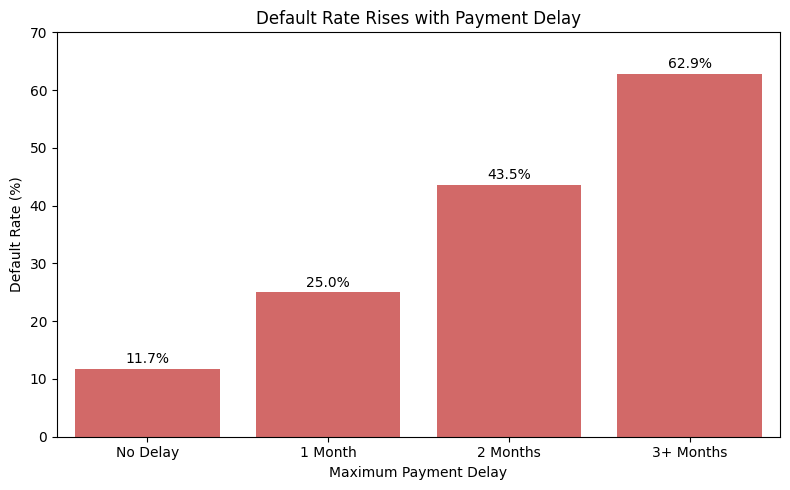

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# delay_order is a variable storing the chart order
delay_order = ["No Delay", "1 Month", "2 Months", "3+ Months"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=delay_group_analysis,
    x="delay_group",
    y="default_rate_pct",
    order=delay_order,
    color="#E45756"
)

# Write percentage above every bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.title("Default Rate Rises with Payment Delay")
plt.xlabel("Maximum Payment Delay")
plt.ylabel("Default Rate (%)")
plt.ylim(0, 70)
plt.tight_layout()
plt.show()

# Chart 2: Default Rate by Credit Utilization Band

This chart compares default rates across different credit-utilization levels.

In [79]:
# utilization_band_analysis stores utilization-group results
utilization_band_analysis = (
    df_clean.groupby("utilization_band", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        default_customers=("default_flag", "sum")
    )
    .reset_index()
)

# Calculate default-rate percentage
utilization_band_analysis["default_rate_pct"] = (
    utilization_band_analysis["default_customers"]
    / utilization_band_analysis["total_customers"]
    * 100
).round(2)

utilization_band_analysis

,utilization_band,total_customers,default_customers,default_rate_pct
0,Low (0-30%),15259,2730,17.89
1,Moderate (30-60%),5474,1201,21.94
2,High (60-100%),8631,2488,28.83
3,Over Limit (>100%),636,217,34.12


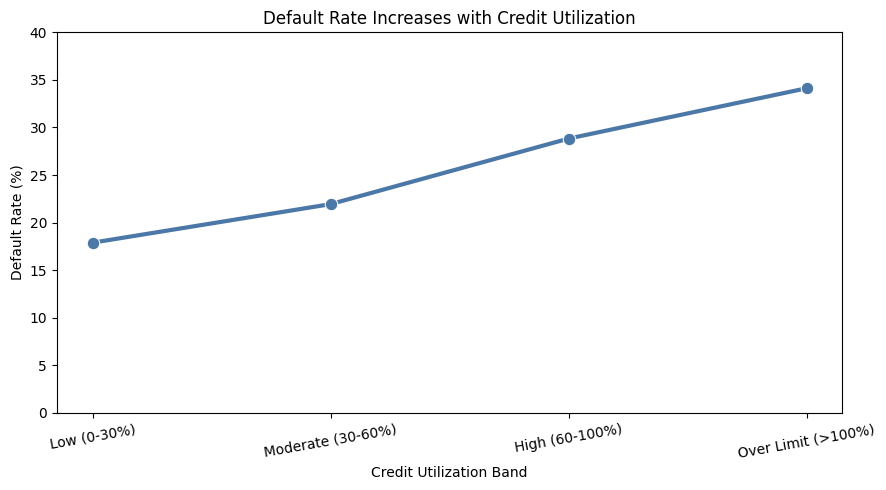

In [80]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=utilization_band_analysis,
    x="utilization_band",
    y="default_rate_pct",
    marker="o",
    linewidth=3,
    markersize=9,
    color="#4C78A8"
)

plt.title("Default Rate Increases with Credit Utilization")
plt.xlabel("Credit Utilization Band")
plt.ylabel("Default Rate (%)")
plt.ylim(0, 40)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Chart 3: Default Rate by Risk Segment

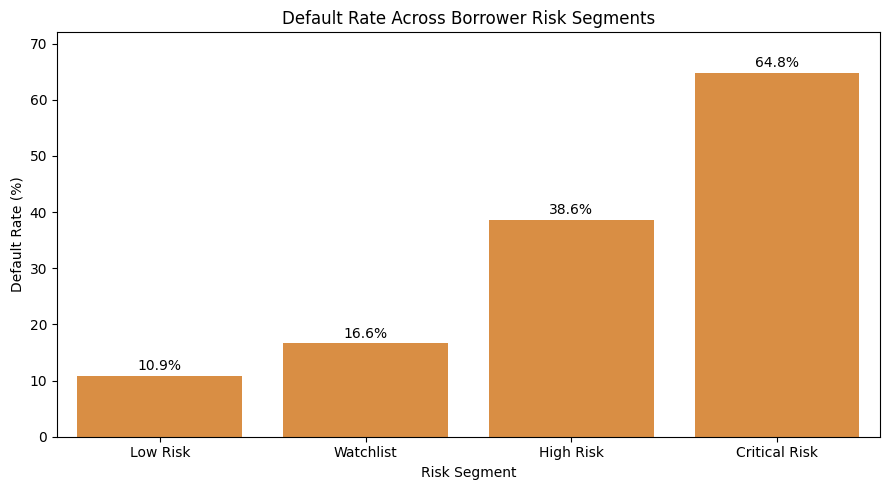

In [77]:
# risk_order is a variable storing the chart order
risk_order = [
    "Low Risk",
    "Watchlist",
    "High Risk",
    "Critical Risk"
]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=risk_segment_analysis,
    x="risk_segment",
    y="default_rate_pct",
    order=risk_order,
    color="#F28E2B"
)

# Write percentage above every bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.title("Default Rate Across Borrower Risk Segments")
plt.xlabel("Risk Segment")
plt.ylabel("Default Rate (%)")
plt.ylim(0, 72)
plt.tight_layout()
plt.show()

**Save Final Dataset**

In [ ]:
# final_file_path is a variable storing the correct save location
final_file_path = (
    "/content/drive/MyDrive/"
    "slice-credit-risk-analysis/Data/"
    "credit_risk_final_dataset.csv"
)

df_clean.to_csv(final_file_path, index=False)

print("Final dataset saved successfully.")